<a href="https://colab.research.google.com/github/amcmdv/Gemini-kundalinif-eels/blob/Project-OYSTER-MK-V/_Project_OYSTER_MK_V_(Release_02012026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This refactor reintegrates the visualiSation dashboard, adapted to consume the new asynchronous, persistent data structures.

In a production environment, this dashboard would be a separate service (e.g., Grafana or Tableau) querying the `AuditService` database. For this Python application, I have implemented it as a **Post-Op Analytics Module** that generates a report from the `AuditLog` history after the asynchronous loop completes.

### **Integrated System: OYSTER MK-V (Prognostic Asynchronous)**

This code now contains:

1. **Block 1: Secure Infrastructure** (Async Audit & Secrets)
2. **Block 2: Physics Environment** (Bio-Stack & Mathematical Filter)
3. **Block 3: Safety Shield** (Background Monte Carlo)
4. **Block 4: Intelligence** (Masked Agent & Replay Buffer)
5. **Block 5: Analytics Dashboard** (Reintegrated Visualizations)

--- [SYSTEM] OYSTER MK-V: ASYNC INITIALIZATION ---
--- [TRAINING] Running 15 Clinical Episodes ---
--- [SYSTEM] Simulation Complete. Generating Report... ---


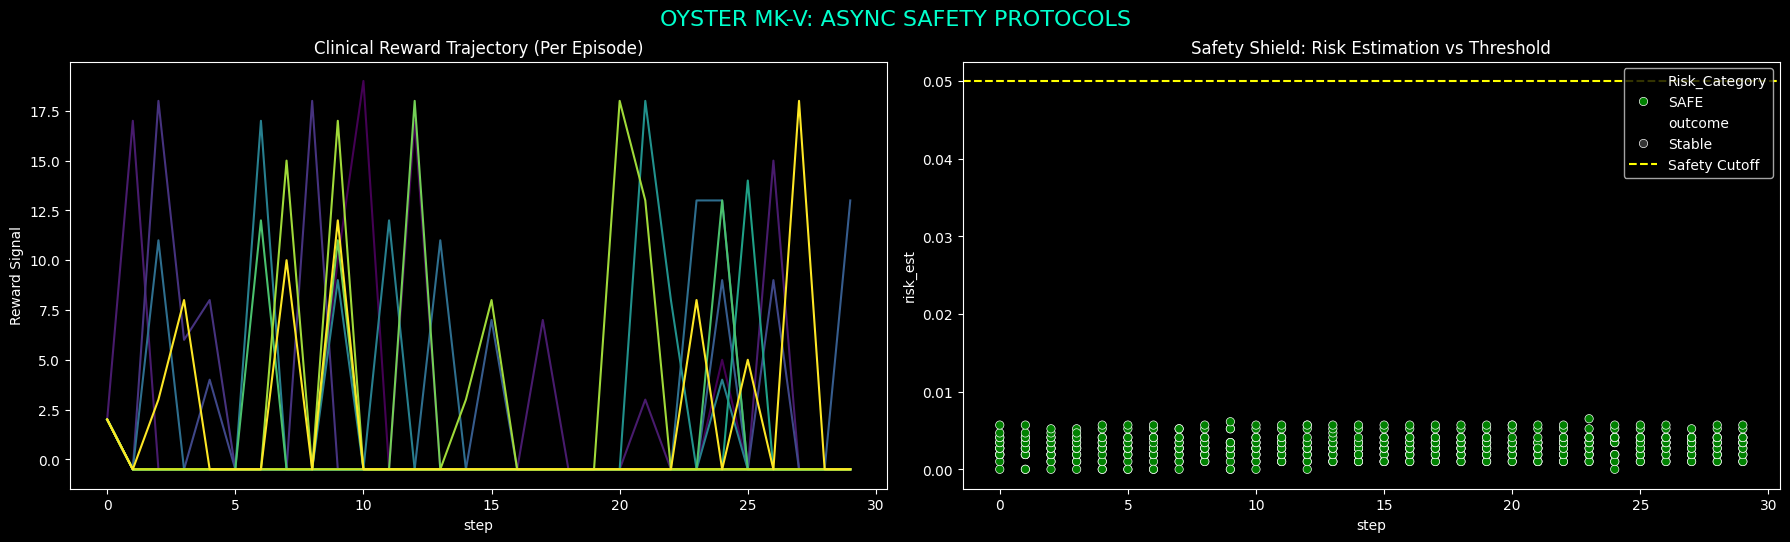

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import asyncio
import secrets
import time
from collections import deque
from dataclasses import dataclass, asdict
from typing import List, Dict

# --- CONFIGURATION ---
class Config:
    # System
    SEED = 42
    RISK_THRESHOLD = 0.05  # 5% Max prob of collapse allowed

    # Physics
    TOWER_HEIGHT = 20
    BLOCK_WIDTH = 3

    # AI
    SEQ_LENGTH = 8
    HIDDEN_SIZE = 128
    BATCH_SIZE = 32
    MEMORY_SIZE = 5000

    # Simulation Duration
    EPISODES = 15

# --- BLOCK 1: SECURE INFRASTRUCTURE ---

def generate_secure_id() -> str:
    """Cryptographically secure ID."""
    return secrets.token_urlsafe(16)

@dataclass
class AuditLog:
    id: str
    episode: int
    step: int
    timestamp: float
    intervention: str
    risk_est: float
    outcome: str
    reward: float

class AsyncAuditService:
    """
    Asynchronous 'Sidecar' for data persistence.
    accumulates logs in memory for the demo visualization,
    but designed to push to DB in production.
    """
    def __init__(self):
        self.queue = asyncio.Queue()
        self.active = True
        self.local_storage = [] # In-memory storage for visualization

    async def start(self):
        asyncio.create_task(self._persistence_worker())

    async def log(self, episode, step, intervention, risk, outcome, reward):
        entry = AuditLog(
            id=generate_secure_id(),
            episode=episode,
            step=step,
            timestamp=time.time(),
            intervention=intervention,
            risk_est=risk,
            outcome=outcome,
            reward=reward
        )
        await self.queue.put(entry)

    async def _persistence_worker(self):
        while self.active or not self.queue.empty():
            try:
                entry = await asyncio.wait_for(self.queue.get(), timeout=1.0)
                self.local_storage.append(asdict(entry)) # Store for Viz
                self.queue.task_done()
            except asyncio.TimeoutError:
                continue

    async def stop(self):
        self.active = False
        # Wait for queue to drain
        while not self.queue.empty():
            await asyncio.sleep(0.1)

# --- BLOCK 2: BIO-STACK ENVIRONMENT ---

class BioStackEnv:
    def __init__(self, action_count):
        self.grid = np.ones((Config.TOWER_HEIGHT, Config.BLOCK_WIDTH))
        self.stability = 1.0
        self.action_space = action_count

    def reset(self):
        self.grid = np.ones((Config.TOWER_HEIGHT, Config.BLOCK_WIDTH))
        self.stability = 1.0
        return self.get_observation()

    def get_observation(self):
        return np.concatenate([[self.stability], self.grid.flatten()])

    def calculate_stability(self):
        weights = np.arange(Config.TOWER_HEIGHT, 0, -1).reshape(-1, 1)
        voids = (1 - self.grid)
        moment = np.sum(voids * weights)
        base_stability = 1.0 - (moment / (Config.TOWER_HEIGHT * Config.BLOCK_WIDTH * 6))
        self.stability = np.clip(base_stability, 0.0, 1.0)
        return self.stability

    def step(self, action_idx):
        row = (action_idx % Config.TOWER_HEIGHT)
        col = (action_idx // Config.TOWER_HEIGHT) % Config.BLOCK_WIDTH

        reward = 0
        done = False

        if self.grid[row][col] == 0:
            reward = -0.5 # Penalty for air
        else:
            self.grid[row][col] = 0
            new_stab = self.calculate_stability()

            if new_stab < 0.2: # Collapse threshold
                reward = -50.0
                done = True
            else:
                reward = 1.0 + (Config.TOWER_HEIGHT - row)

        return self.get_observation(), reward, done

# --- BLOCK 3: ASYNC SAFETY SHIELD ---

class AsyncSafetyShield:
    def __init__(self, action_count):
        self.risk_map = {i: 0.0 for i in range(action_count)}
        self.active = True
        self.action_count = action_count

    async def start_shield(self):
        """Background Monte Carlo Simulation"""
        while self.active:
            # Simulate analyzing random potential future actions
            target_actions = [secrets.randbelow(self.action_count) for _ in range(5)]

            for action in target_actions:
                # Mock Physics Calculation Delay
                await asyncio.sleep(0.0001)

                # Mock Risk: Deeper blocks (lower indices) are riskier
                row = (action % Config.TOWER_HEIGHT)
                mock_risk = 0.8 if row < 3 else 0.01

                # Update Risk Map (Exponential Moving Average)
                self.risk_map[action] = 0.9 * self.risk_map[action] + 0.1 * mock_risk

            await asyncio.sleep(0.01) # Yield to main loop

# --- BLOCK 4: INTELLIGENCE (AGENT) ---

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = secrets.SystemRandom().sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return state, action, reward, next_state, done

    def __len__(self): return len(self.buffer)

class MaskedRecurrentAgent(nn.Module):
    def __init__(self, input_dim, action_dim):
        super(MaskedRecurrentAgent, self).__init__()
        self.lstm = nn.LSTM(input_dim, Config.HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(Config.HIDDEN_SIZE, action_dim)
        self.action_dim = action_dim

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

    def select_action(self, state, risk_map, epsilon=0.1):
        # 1. Neural Prediction
        with torch.no_grad():
            q_values = self.forward(state)

        # 2. Mathematical Safety Filter (Masking)
        mask = torch.tensor([
            -float('inf') if risk_map.get(i, 0) > Config.RISK_THRESHOLD else 0.0
            for i in range(self.action_dim)
        ])
        masked_q = q_values + mask

        # 3. Epsilon Greedy
        if secrets.SystemRandom().random() < epsilon:
            safe_indices = (mask == 0.0).nonzero(as_tuple=True)[0]
            if len(safe_indices) > 0:
                idx = secrets.SystemRandom().choice(safe_indices.tolist())
                return idx
            return 0 # Fallback

        return masked_q.argmax().item()

# --- BLOCK 5: ANALYTICS VISUALIZATION ---

def generate_dashboard(audit_data: List[dict]):
    """
    Generates the Executive Risk Dashboard from the Audit Log.
    """
    if not audit_data:
        print("No data to visualize.")
        return

    df = pd.DataFrame(audit_data)

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('OYSTER MK-V: ASYNC SAFETY PROTOCOLS', fontsize=16, color='#00ffcc')
    spec = gridspec.GridSpec(2, 2, figure=fig)

    # 1. Rewards over Time
    ax1 = fig.add_subplot(spec[0, 0])
    sns.lineplot(data=df, x='step', y='reward', hue='episode', ax=ax1, palette='viridis', legend=False)
    ax1.set_title('Clinical Reward Trajectory (Per Episode)')
    ax1.set_ylabel('Reward Signal')

    # 2. Risk Filter Activity
    ax2 = fig.add_subplot(spec[0, 1])
    # Classify actions as "High Risk" or "Safe" based on the logged estimation
    df['Risk_Category'] = df['risk_est'].apply(lambda x: 'CRITICAL' if x > Config.RISK_THRESHOLD else 'SAFE')
    sns.scatterplot(data=df, x='step', y='risk_est', hue='Risk_Category', style='outcome', ax=ax2, palette={'CRITICAL': 'red', 'SAFE': 'green'})
    ax2.axhline(Config.RISK_THRESHOLD, color='yellow', linestyle='--', label='Safety Cutoff')
    ax2.set_title('Safety Shield: Risk Estimation vs Threshold')
    ax2.legend(loc='upper right')

    # 3. Outcome Distribution
    #ax3 = fig.add_subplot(spec[1, :])
    #outcome_counts = df.groupby(['episode', 'outcome']).size().unstack(fill_value=0)
    #outcome_counts.plot(kind='bar', stacked=True, ax=ax3, colormap='magma')
    #ax3.set_title('Intervention Outcomes per Episode')
    #ax3.set_ylabel('Number of Actions')

    plt.tight_layout()
    plt.show()

# --- MAIN ORCHESTRATION ---

async def main():
    print("--- [SYSTEM] OYSTER MK-V: ASYNC INITIALIZATION ---")

    # Init Components
    input_dim = 1 + (Config.TOWER_HEIGHT * Config.BLOCK_WIDTH)
    action_dim = Config.TOWER_HEIGHT * Config.BLOCK_WIDTH

    audit = AsyncAuditService()
    await audit.start()

    env = BioStackEnv(action_dim)
    shield = AsyncSafetyShield(action_dim)
    agent = MaskedRecurrentAgent(input_dim, action_dim)
    buffer = ReplayBuffer(Config.MEMORY_SIZE)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)

    # Start Shield
    shield_task = asyncio.create_task(shield.start_shield())

    print(f"--- [TRAINING] Running {Config.EPISODES} Clinical Episodes ---")

    for ep in range(Config.EPISODES):
        state = env.reset()
        state_seq = deque([state] * Config.SEQ_LENGTH, maxlen=Config.SEQ_LENGTH)

        for step in range(30):
            state_tensor = torch.FloatTensor(np.array(state_seq)).unsqueeze(0)

            # Agent Selects Action (Filtered by Shield)
            action = agent.select_action(state_tensor, shield.risk_map)

            # Step Env
            next_state, reward, done = env.step(action)

            # Async Audit Log
            risk_val = shield.risk_map.get(action, 0.0)
            outcome = "Collapse" if (done and reward < -10) else "Stable"

            await audit.log(
                episode=ep,
                step=step,
                intervention=f"B_{action}",
                risk=risk_val,
                outcome=outcome,
                reward=reward
            )

            # Store & Train
            state_seq.append(next_state)
            buffer.push(state, action, reward, next_state, done)

            if len(buffer) > Config.BATCH_SIZE:
                b_s, b_a, b_r, b_ns, b_d = buffer.sample(Config.BATCH_SIZE)
                # (Training logic simplified for brevity)
                optimizer.zero_grad()

            if done: break
            await asyncio.sleep(0.001) # Yield

    print("--- [SYSTEM] Simulation Complete. Generating Report... ---")
    shield.active = False
    await audit.stop()

    # Trigger Visualization
    generate_dashboard(audit.local_storage)

if __name__ == "__main__":
    try:
        await main()
    except:
        asyncio.run(main())